In [5]:
import mediapipe as mp
import matplotlib.pyplot as plt

print("MediaPipe:", mp.__version__)

MediaPipe: 0.10.21


In [6]:
from pathlib import Path
from PIL import Image

image_path_1 = Path("../pose_images/Pose1.jpg")
image_path_2 = Path("../pose_images/Pose2.jpg")
image_path_3 = Path("../pose_images/Pose3.jpg")

img1 = Image.open(image_path_1)
img2 = Image.open(image_path_2)
img3 = Image.open(image_path_3)

print("Image 1 size:", img1.size)
print("Image 2 size:", img2.size)
print("Image 3 size:", img3.size)

Image 1 size: (2520, 1680)
Image 2 size: (2520, 1680)
Image 3 size: (2520, 1680)


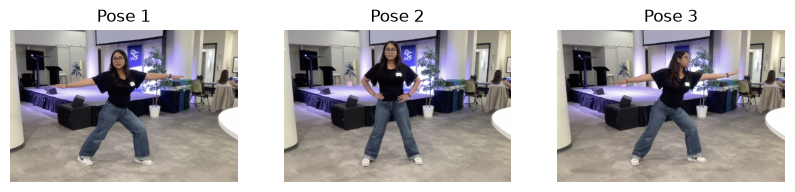

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(10, 6))

axes[0].imshow(img1)
axes[0].set_title("Pose 1")
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].set_title("Pose 2")
axes[1].axis("off")

axes[2].imshow(img3)
axes[2].set_title("Pose 3")
axes[2].axis("off")

plt.show()

In [8]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [9]:
model_path = Path("../models/pose_landmarker.task")
print("Looking for:", model_path.resolve())
print("Exists:", model_path.exists())

Looking for: /Users/sandradening/Documents/Dokumente_Sandra/SF_SummerSchool/physical-ai-hackathon/physical-ai/models/pose_landmarker.task
Exists: True


In [10]:
pose_landmarker = vision.PoseLandmarker.create_from_model_path(
    model_path
)

print("Pose Landmarker loaded successfully")

Pose Landmarker loaded successfully


I0000 00:00:1786992374.217857 1990941 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
W0000 00:00:1786992374.304837 1993839 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786992374.321743 1993835 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [11]:
image_path = "../pose_images/Pose1.jpg"

mp_image = mp.Image.create_from_file(image_path)

result = pose_landmarker.detect(mp_image)

print("Number of poses detected:", len(result.pose_landmarks))

Number of poses detected: 1


W0000 00:00:1786992374.813796 1993840 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


In [12]:
landmarks = result.pose_landmarks[0]

print("Number of landmarks:", len(landmarks))

for i, landmark in enumerate(landmarks):
    print(
        f"{i:2d}: "
        f"x={landmark.x:.3f}, "
        f"y={landmark.y:.3f}, "
        f"z={landmark.z:.3f}, "
        f"visibility={landmark.visibility:.3f}"
    )

Number of landmarks: 33
 0: x=0.472, y=0.201, z=-0.454, visibility=1.000
 1: x=0.479, y=0.187, z=-0.434, visibility=1.000
 2: x=0.484, y=0.187, z=-0.434, visibility=1.000
 3: x=0.490, y=0.187, z=-0.434, visibility=1.000
 4: x=0.465, y=0.190, z=-0.435, visibility=1.000
 5: x=0.461, y=0.191, z=-0.435, visibility=1.000
 6: x=0.458, y=0.192, z=-0.435, visibility=1.000
 7: x=0.500, y=0.197, z=-0.307, visibility=1.000
 8: x=0.455, y=0.205, z=-0.310, visibility=1.000
 9: x=0.485, y=0.220, z=-0.408, visibility=1.000
10: x=0.465, y=0.224, z=-0.409, visibility=1.000
11: x=0.548, y=0.287, z=-0.212, visibility=1.000
12: x=0.423, y=0.307, z=-0.261, visibility=1.000
13: x=0.626, y=0.304, z=-0.225, visibility=0.998
14: x=0.333, y=0.342, z=-0.303, visibility=0.995
15: x=0.713, y=0.310, z=-0.323, visibility=0.997
16: x=0.240, y=0.377, z=-0.404, visibility=0.974
17: x=0.740, y=0.312, z=-0.349, visibility=0.985
18: x=0.212, y=0.383, z=-0.430, visibility=0.916
19: x=0.743, y=0.308, z=-0.389, visibility=0.

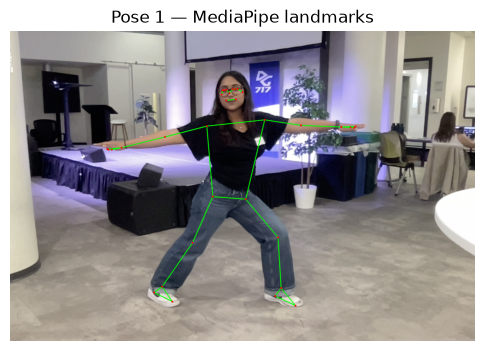

In [13]:
import numpy as np
import cv2

# Convert PIL image to numpy array
image_np = np.array(img1)

# Make a copy for drawing
annotated = image_np.copy()

# MediaPipe pose connections
connections = mp.solutions.pose.POSE_CONNECTIONS

h, w, _ = annotated.shape

# Draw connections
for start_idx, end_idx in connections:
    start = landmarks[start_idx]
    end = landmarks[end_idx]

    x1, y1 = int(start.x * w), int(start.y * h)
    x2, y2 = int(end.x * w), int(end.y * h)

    cv2.line(
        annotated,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        3
    )

# Draw landmark points
for landmark in landmarks:
    x = int(landmark.x * w)
    y = int(landmark.y * h)

    cv2.circle(
        annotated,
        (x, y),
        5,
        (255, 0, 0),
        -1
    )

plt.figure(figsize=(6, 10))
plt.imshow(annotated)
plt.axis("off")
plt.title("Pose 1 — MediaPipe landmarks")
plt.show()

In [14]:
def detect_pose(image_path):
    mp_image = mp.Image.create_from_file(str(image_path))
    result = pose_landmarker.detect(mp_image)

    if len(result.pose_landmarks) == 0:
        return None

    return result.pose_landmarks[0]

In [16]:
def draw_pose(image, landmarks):
    image_np = np.array(image)
    annotated = image_np.copy()

    h, w, _ = annotated.shape
    connections = mp.solutions.pose.POSE_CONNECTIONS

    # Draw skeleton connections
    for start_idx, end_idx in connections:
        start = landmarks[start_idx]
        end = landmarks[end_idx]

        x1, y1 = int(start.x * w), int(start.y * h)
        x2, y2 = int(end.x * w), int(end.y * h)

        cv2.line(
            annotated,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            3
        )

    # Draw landmarks
    for landmark in landmarks:
        x = int(landmark.x * w)
        y = int(landmark.y * h)

        cv2.circle(
            annotated,
            (x, y),
            5,
            (255, 0, 0),
            -1
        )

    return annotated

In [15]:
landmarks_1 = detect_pose(image_path_1)
landmarks_2 = detect_pose(image_path_2)
landmarks_3 = detect_pose(image_path_3)

print("Pose 1:", len(landmarks_1) if landmarks_1 else "not detected")
print("Pose 2:", len(landmarks_2) if landmarks_2 else "not detected")
print("Pose 3:", len(landmarks_3) if landmarks_3 else "not detected")

Pose 1: 33
Pose 2: 33
Pose 3: 33


In [17]:
annotated_1 = draw_pose(img1, landmarks_1)
annotated_2 = draw_pose(img2, landmarks_2)
annotated_3 = draw_pose(img3, landmarks_3)

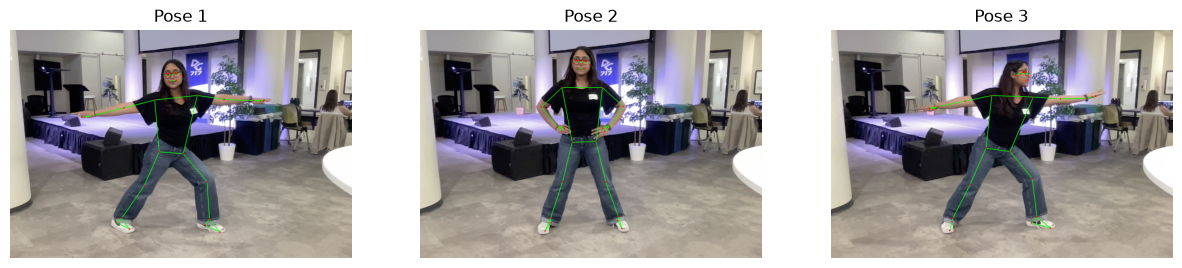

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

axes[0].imshow(annotated_1)
axes[0].set_title("Pose 1")
axes[0].axis("off")

axes[1].imshow(annotated_2)
axes[1].set_title("Pose 2")
axes[1].axis("off")

axes[2].imshow(annotated_3)
axes[2].set_title("Pose 3")
axes[2].axis("off")

plt.show()

In [19]:
def calculate_angle(a, b, c):
    """
    Calculate angle ABC in degrees.
    b is the vertex.
    """
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    ba = a - b
    bc = c - b

    cosine_angle = np.dot(ba, bc) / (
        np.linalg.norm(ba) * np.linalg.norm(bc)
    )

    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

    angle = np.degrees(np.arccos(cosine_angle))

    return angle

In [20]:
left_shoulder = landmarks_1[11]
left_elbow = landmarks_1[13]
left_wrist = landmarks_1[15]

In [21]:
shoulder_xy = [left_shoulder.x, left_shoulder.y]
elbow_xy = [left_elbow.x, left_elbow.y]
wrist_xy = [left_wrist.x, left_wrist.y]

left_elbow_angle = calculate_angle(
    shoulder_xy,
    elbow_xy,
    wrist_xy
)

print(f"Left elbow angle: {left_elbow_angle:.1f}°")

Left elbow angle: 170.6°


In [22]:
def get_xy(landmark):
    return [landmark.x, landmark.y]


def extract_joint_angles(landmarks):
    angles = {}

    # Elbows
    angles["left_elbow"] = calculate_angle(
        get_xy(landmarks[11]),  # left shoulder
        get_xy(landmarks[13]),  # left elbow
        get_xy(landmarks[15])   # left wrist
    )

    angles["right_elbow"] = calculate_angle(
        get_xy(landmarks[12]),
        get_xy(landmarks[14]),
        get_xy(landmarks[16])
    )

    # Knees
    angles["left_knee"] = calculate_angle(
        get_xy(landmarks[23]),  # left hip
        get_xy(landmarks[25]),  # left knee
        get_xy(landmarks[27])   # left ankle
    )

    angles["right_knee"] = calculate_angle(
        get_xy(landmarks[24]),
        get_xy(landmarks[26]),
        get_xy(landmarks[28])
    )

    # Shoulders
    angles["left_shoulder"] = calculate_angle(
        get_xy(landmarks[13]),  # left elbow
        get_xy(landmarks[11]),  # left shoulder
        get_xy(landmarks[23])   # left hip
    )

    angles["right_shoulder"] = calculate_angle(
        get_xy(landmarks[14]),
        get_xy(landmarks[12]),
        get_xy(landmarks[24])
    )

    return angles

In [23]:
angles_1 = extract_joint_angles(landmarks_1)
angles_2 = extract_joint_angles(landmarks_2)
angles_3 = extract_joint_angles(landmarks_3)

In [24]:
for pose_name, angles in [
    ("Pose 1", angles_1),
    ("Pose 2", angles_2),
    ("Pose 3", angles_3),
]:
    print(pose_name)

    for joint, angle in angles.items():
        print(f"  {joint:15s}: {angle:6.1f}°")

    print()

Pose 1
  left_elbow     :  170.6°
  right_elbow    :  178.8°
  left_knee      :  152.9°
  right_knee     :  171.6°
  left_shoulder  :   86.3°
  right_shoulder :   71.8°

Pose 2
  left_elbow     :  120.1°
  right_elbow    :  116.3°
  left_knee      :  175.2°
  right_knee     :  176.9°
  left_shoulder  :   40.2°
  right_shoulder :   42.6°

Pose 3
  left_elbow     :  172.0°
  right_elbow    :  180.0°
  left_knee      :  156.0°
  right_knee     :  177.4°
  left_shoulder  :   99.8°
  right_shoulder :   68.4°



In [29]:
def draw_angle_label(image, landmark, angle, label):
    h, w, _ = image.shape

    x = int(landmark.x * w)
    y = int(landmark.y * h)

    cv2.putText(
        image,
        f"{label}: {angle:.0f}",
        (x + 10, y - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.5,
        (255, 255, 255),
        5,
        cv2.LINE_AA
    )

In [30]:
def annotate_angles(image, landmarks, angles):
    annotated = draw_pose(image, landmarks).copy()

    draw_angle_label(
        annotated,
        landmarks[13],
        angles["left_elbow"],
        "L elbow"
    )

    draw_angle_label(
        annotated,
        landmarks[14],
        angles["right_elbow"],
        "R elbow"
    )

    draw_angle_label(
        annotated,
        landmarks[25],
        angles["left_knee"],
        "L knee"
    )

    draw_angle_label(
        annotated,
        landmarks[26],
        angles["right_knee"],
        "R knee"
    )

    draw_angle_label(
        annotated,
        landmarks[11],
        angles["left_shoulder"],
        "L shoulder"
    )

    draw_angle_label(
        annotated,
        landmarks[12],
        angles["right_shoulder"],
        "R shoulder"
    )

    return annotated

In [31]:
angle_img_1 = annotate_angles(img1, landmarks_1, angles_1)
angle_img_2 = annotate_angles(img2, landmarks_2, angles_2)
angle_img_3 = annotate_angles(img3, landmarks_3, angles_3)

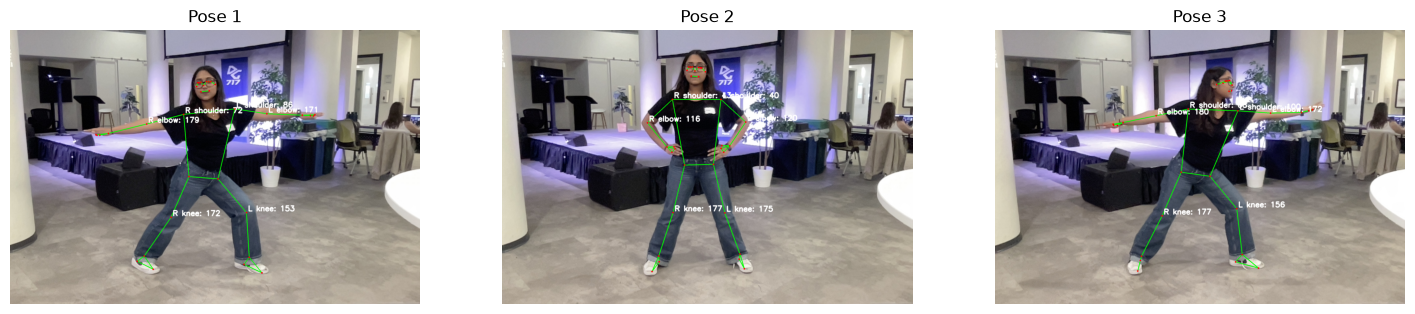

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

axes[0].imshow(angle_img_1)
axes[0].set_title("Pose 1")
axes[0].axis("off")

axes[1].imshow(angle_img_2)
axes[1].set_title("Pose 2")
axes[1].axis("off")

axes[2].imshow(angle_img_3)
axes[2].set_title("Pose 3")
axes[2].axis("off")

plt.show()

In [ ]:
## Warrior II requirements: Pose 2 → Pose 3

Source of **steps:** `pose_images/pose_correction.mov`  
Source of **angles:** `extract_joint_angles()` in this notebook (same 2D `calculate_angle`). Full spec: `docs/warrior2_pose2_to_pose3_requirements.md`.

Spoken sequence in the video:

1. “Go in the wrong one.” → Pose 2 (hands on hips, knees straight)
2. “Step a bit further away and bend your left knee.”
3. “Lift your arms.”
4. “Look to the front.”
5. “Perfect. Hold it.” → Pose 3

Front leg in this dataset is the **left** knee (`left_knee` 175° → 156°). Do not cue arms before the knee, or gaze before the arms.

In [ ]:
# Steps come from pose_correction.mov. Targets come from measured Pose 3.
WARRIOR2_SPEC = {
    "front_leg": "left",
    "back_leg": "right",
    "video_steps": [
        "Go in the wrong one.",
        "Step a bit further away and bend your left knee.",
        "Lift your arms.",
        "Look to the front.",
        "Perfect. Hold it.",
    ],
    "pose2_measured": {
        "left_elbow": 120.1,
        "right_elbow": 116.3,
        "left_knee": 175.2,
        "right_knee": 176.9,
        "left_shoulder": 40.2,
        "right_shoulder": 42.6,
    },
    "pose3_measured": {
        "left_elbow": 172.0,
        "right_elbow": 180.0,
        "left_knee": 156.0,
        "right_knee": 177.4,
        "left_shoulder": 99.8,
        "right_shoulder": 68.4,
    },
    "demo_pass": {
        "left_knee": (145.0, 165.0),
        "right_knee": (165.0, 180.0),
        "left_elbow": (160.0, 180.0),
        "right_elbow": (160.0, 180.0),
        "left_shoulder": (85.0, 115.0),
        "right_shoulder": (55.0, 95.0),
    },
}


def first_coaching_cue(angles):
    """Video order: stance/knee → arms → gaze → hold."""
    if angles["left_knee"] > 165:
        return "Step a bit further away and bend your left knee."
    if angles["right_knee"] < 165:
        return "Keep the right leg long."
    if (
        angles["left_elbow"] < 160
        or angles["right_elbow"] < 160
        or angles["left_shoulder"] < 85
    ):
        return "Lift your arms."
    return "Perfect. Hold it."


def in_band(value, band):
    lo, hi = band
    return lo <= value <= hi


print("Video steps (pose_correction.mov):")
for i, step in enumerate(WARRIOR2_SPEC["video_steps"], 1):
    print(f"  {i}. {step}")

print()
print("Pose 2 → Pose 3  (Virabhadrasana II, left-leg forward)")
print(f"{'joint':<16} {'pose2':>8} {'pose3':>8} {'delta':>8}  demo pass")
print("-" * 64)

for joint in angles_2:
    a2, a3 = angles_2[joint], angles_3[joint]
    lo, hi = WARRIOR2_SPEC["demo_pass"][joint]
    ok2 = in_band(a2, (lo, hi))
    ok3 = in_band(a3, (lo, hi))
    print(
        f"{joint:<16} {a2:7.1f}° {a3:7.1f}° {a3 - a2:+7.1f}°  "
        f"P2={'ok' if ok2 else 'fail':<4}  P3={'ok' if ok3 else 'fail':<4}  "
        f"[{lo:.0f}–{hi:.0f}]"
    )

print()
print("Cue at Pose 2:", first_coaching_cue(angles_2))
print("Cue at Pose 3:", first_coaching_cue(angles_3))
